<a href="https://colab.research.google.com/github/LIBY70/-goinhwal/blob/Hw/hw5_22012167_%EB%85%B8%EC%A3%BC%ED%98%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

In [20]:
data = pd.read_csv('titanic.csv')
data.drop(columns=['Name','Ticket'],inplace=True)
#생존여부 확인에 도움이 되지 않음
#name의 경우 전처리를 통하여 성별, 나이, 호칭 등을 추출할 수 있으나 본 분석에서 유의미를 가지기 어렵다고 판단하여 제거
data.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Embarked,0
Survived,0


In [21]:
data.head()

,Pclass,Sex,Age,SibSp,Parch,Embarked,Survived
0,3,male,22.0,1,0,S,0
1,1,female,38.0,1,0,C,1
2,3,female,26.0,0,0,S,1
3,1,female,35.0,1,0,S,1
4,3,male,35.0,0,0,S,0


In [22]:
from sklearn.preprocessing import LabelEncoder

cat_feature = ['Sex']
encoder = LabelEncoder()
for i in cat_feature:
    data[i] = encoder.fit_transform(data[i])

embarked_mapping = {
    "S" : 0,
    "Q" : 1,
    "C" : 2
}

data['Embarked'] = data['Embarked'].map(embarked_mapping)


In [23]:
data

,Pclass,Sex,Age,SibSp,Parch,Embarked,Survived
0,3,1,22.0,1,0,0,0
1,1,0,38.0,1,0,2,1
2,3,0,26.0,0,0,0,1
3,1,0,35.0,1,0,0,1
4,3,1,35.0,0,0,0,0
...,...,...,...,...,...,...,...
884,2,1,27.0,0,0,0,0
885,1,0,19.0,0,0,0,1
886,3,0,28.0,1,2,0,0
887,1,1,26.0,0,0,2,1


In [24]:
X = data.drop(columns=['Survived'])
y = data['Survived']

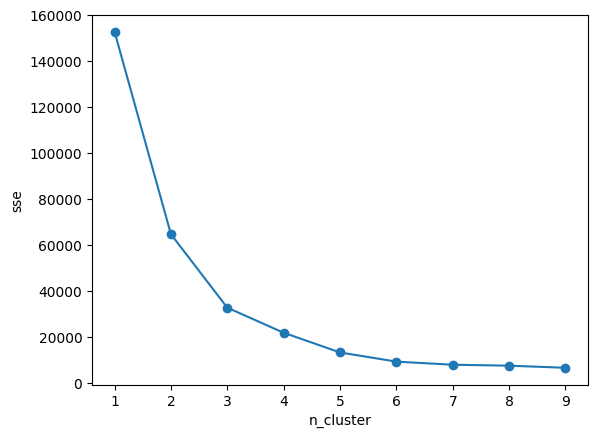

In [25]:
#군집 개수K 설정 elbow method
#clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def elbow(X):
    sse = []
    for i in range(1,10):
        km = KMeans(n_clusters=i,init='k-means++',random_state=0)
        km.fit(X)
        sse.append(km.inertia_)
    plt.plot(range(1,10),sse,marker='o')
    plt.xlabel('n_cluster')
    plt.ylabel('sse')
    plt.show()

elbow(X)

In [26]:
#위 그래프를 통해 군집 개수를 3이 적절함을 알 수 없다.

scaler = StandardScaler()
data_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3,random_state=0)
kmeans.fit(data_scaled)
cluster = kmeans.predict(data_scaled)
X['cluster'] = cluster
X


,Pclass,Sex,Age,SibSp,Parch,Embarked,cluster
0,3,1,22.0,1,0,0,0
1,1,0,38.0,1,0,2,1
2,3,0,26.0,0,0,0,2
3,1,0,35.0,1,0,0,2
4,3,1,35.0,0,0,0,0
...,...,...,...,...,...,...,...
884,2,1,27.0,0,0,0,0
885,1,0,19.0,0,0,0,2
886,3,0,28.0,1,2,0,2
887,1,1,26.0,0,0,2,1


In [27]:
#군집별 생존자 수
X['Survived'] = y
X.groupby(['cluster'])['Survived'].sum()


,Survived
cluster,
0,67
1,90
2,183


In [28]:
#군집별 생존률
X.groupby(['cluster'])['Survived'].mean()
#군집별 생존률을 보면 0번 군집의 생존률이 가장 높고 1번 군집의 생존률이 가장 낮다.


,Survived
cluster,
0,0.153318
1,0.542169
2,0.639860


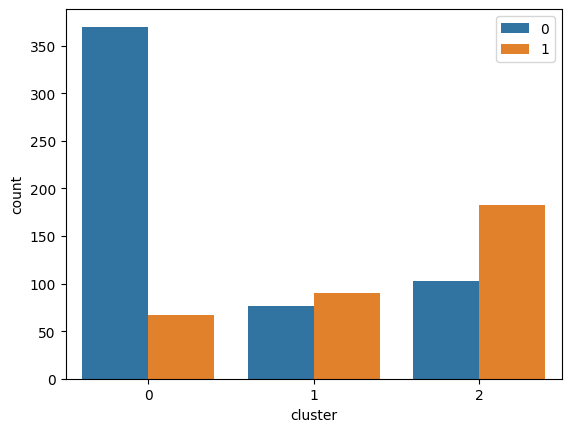

In [29]:
#군집별 생존자 수 시각화
sns.countplot(x='cluster',hue='Survived',data=X)
plt.legend(loc='upper right')
plt.show()


In [30]:
X

,Pclass,Sex,Age,SibSp,Parch,Embarked,cluster,Survived
0,3,1,22.0,1,0,0,0,0
1,1,0,38.0,1,0,2,1,1
2,3,0,26.0,0,0,0,2,1
3,1,0,35.0,1,0,0,2,1
4,3,1,35.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
884,2,1,27.0,0,0,0,0,0
885,1,0,19.0,0,0,0,2,1
886,3,0,28.0,1,2,0,2,0
887,1,1,26.0,0,0,2,1,1


In [31]:
X[X['cluster'] == 0].describe()


,Pclass,Sex,Age,SibSp,Parch,Embarked,cluster,Survived
count,437.000000,437.000000,437.000000,437.000000,437.000000,437.000000,437.0,437.000000
mean,2.450801,0.986270,32.080092,0.187643,0.057208,0.082380,0.0,0.153318
std,0.766549,0.116501,11.788240,0.450823,0.251463,0.275258,0.0,0.360707
min,1.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,2.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,3.000000,1.000000,28.000000,0.000000,0.000000,0.000000,0.0,0.000000
75%,3.000000,1.000000,37.000000,0.000000,0.000000,0.000000,0.0,0.000000
max,3.000000,1.000000,80.000000,2.000000,2.000000,1.000000,0.0,1.000000


In [32]:
X[X['cluster'] == 1].describe()


,Pclass,Sex,Age,SibSp,Parch,Embarked,cluster,Survived
count,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.0,166.000000
mean,1.843373,0.578313,31.147108,0.367470,0.307229,1.975904,1.0,0.542169
std,0.933964,0.495323,12.796554,0.531347,0.599653,0.153812,0.0,0.499726
min,1.000000,0.000000,0.420000,0.000000,0.000000,1.000000,1.0,0.000000
25%,1.000000,0.000000,24.000000,0.000000,0.000000,2.000000,1.0,0.000000
50%,1.000000,1.000000,28.000000,0.000000,0.000000,2.000000,1.0,1.000000
75%,3.000000,1.000000,36.000000,1.000000,0.000000,2.000000,1.0,1.000000
max,3.000000,1.000000,71.000000,2.000000,2.000000,2.000000,1.0,1.000000


In [33]:
X[X['cluster'] == 2].describe()


,Pclass,Sex,Age,SibSp,Parch,Embarked,cluster,Survived
count,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.0,286.000000
mean,2.370629,0.174825,24.027098,1.129371,0.923077,0.171329,2.0,0.639860
std,0.778467,0.380483,13.274707,1.663028,1.124383,0.429626,0.0,0.480882
min,1.000000,0.000000,0.670000,0.000000,0.000000,0.000000,2.0,0.000000
25%,2.000000,0.000000,16.000000,0.000000,0.000000,0.000000,2.0,0.000000
50%,3.000000,0.000000,27.000000,1.000000,1.000000,0.000000,2.0,1.000000
75%,3.000000,0.000000,31.000000,1.000000,2.000000,0.000000,2.0,1.000000
max,3.000000,1.000000,64.000000,8.000000,6.000000,2.000000,2.0,1.000000


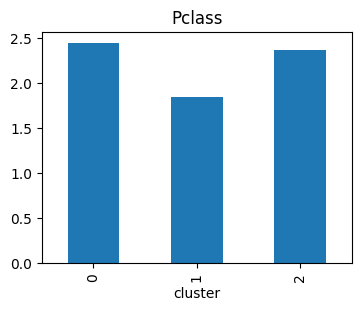

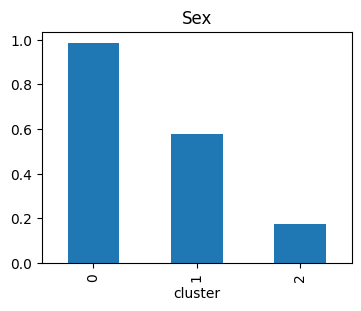

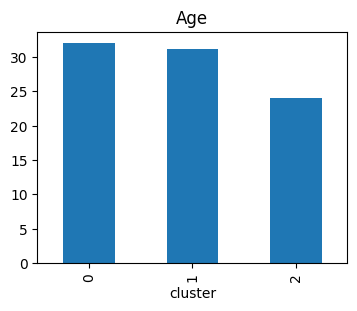

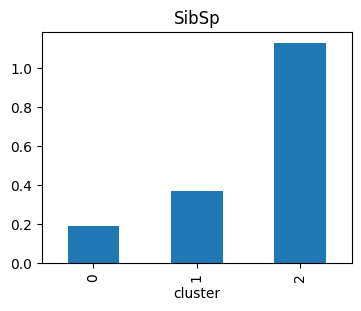

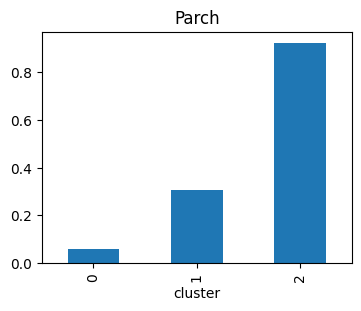

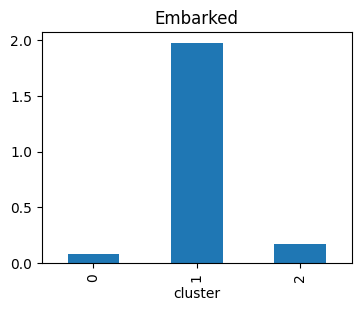

In [34]:
for i in X.iloc[:,:-2]:
    plt.figure(figsize=(4,3))
    X.groupby(['cluster'])[i].mean().plot(kind='bar')

    plt.title(i)
    plt.show()

- 0번 군집의 경우 나이가 비교적 많고, pclass가 높은 사람들이 많음.
- 1번 군집과 2번 군집은 그에 비해 나이가 적고, pclass가 낮은(3등급에 가까운) 사람들이 많음.
- 1번 군집의 가장 두드러지는 특징은 sibsp,parch가 높다. 이는 같이 탄 가족이 많다는 것을 의미함.
- 2번 군집의 큰 특징은 남성이 80% 이상인 것임.

- 이런 클러스트링 결과는 생존률과도 연관이 있음.  
- 실제로 0번 군집은 0.608696, 1번 군집은 0.492958, 2번 군집은 0.216561의 생존률을 보임.

